# Institutional Holdings Knowledge Graph from SEC 13F Filings

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/05_institutional_holdings_kg.py
> ```


This notebook demonstrates building a Knowledge Graph from structured SEC 13F
filings, where multi-hop ownership queries are far more cumbersome with flat
tabular analysis (they require repeated self-joins). 13F filings disclose
quarterly equity holdings for institutional managers with over $100M AUM,
creating a natural bipartite graph connecting institutions to stocks.

**Learning Objectives**:
- Design a property graph schema for institutional ownership data
- Build an in-memory graph and translate ownership questions into Cypher queries
- Compute co-ownership similarity (Jaccard) to detect crowded positions
- Load the holdings graph into Neo4j for persistent querying

**Book Reference**: Chapter 23, Section 23.4 (From Graphs to Machine Learning Features)

**Prerequisites**: Familiarity with graph data models (Section 23.2).
A live Neo4j instance is required for the graph loading step.

In [1]:
"""Build an institutional-ownership graph from structured SEC 13F data."""

from __future__ import annotations

import hashlib
import json
import logging
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_institutional_holdings_13f
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
# Production defaults. Papermill overrides them for testing.
# The stock cap is what shapes the graph: 50 names out of the several thousand
# the cohort discloses. The institution cap is a formality - the artifact holds
# ten managers in total and all ten file in every period - and the run prints
# both caps against the population they were applied to.
N_INSTITUTIONS = 10

## Infrastructure Detection

Detect Neo4j availability for graph loading.

In [3]:
# Neo4j connection settings (from environment or defaults)
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

from neo4j import GraphDatabase

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

# 13F data loads via `load_institutional_holdings_13f()`; the loader raises
# `DataNotFoundError` with download-script + README pointers when the parquet
# produced by `data/equities/positioning/13f_download.py` is missing.

Neo4j connected: bolt://neo4j:7687


## 1. Schema Design

The 13F Knowledge Graph uses a property graph model with three node types
and three relationship types. A HOLDS edge is keyed on `(institution, stock,
report_date)` and carries two dates, because a 13F position has two and they
answer different questions. `report_date` is the quarter-end the position was
held on, which is what a quarter-over-quarter comparison needs.
`available_from` is the filing date on which the position became public,
roughly six weeks later, which is what a point-in-time query needs:
`03_graph_rag_qa` constrains on `h.available_from <= $cutoff_date`. Using
either date for the other question is a look-ahead in one direction and a
misaligned quarter in the other.

In [4]:
# Schema definition
SCHEMA = {
    "nodes": {
        "Institution": ["cik", "name", "equity_13f_value"],
        "Stock": ["cusip", "issuer", "label", "sector"],
        "Sector": ["name"],
    },
    "relationships": {
        "HOLDS": {
            "from": "Institution",
            "to": "Stock",
            "properties": ["shares", "value", "report_date", "available_from"],
        },
        "IN_SECTOR": {"from": "Stock", "to": "Sector", "properties": []},
    },
}

print("Knowledge Graph Schema:")
print(f"  Node Types: {list(SCHEMA['nodes'].keys())}")
print(f"  Relationship Types: {list(SCHEMA['relationships'].keys())}")

Knowledge Graph Schema:
  Node Types: ['Institution', 'Stock', 'Sector']
  Relationship Types: ['HOLDS', 'IN_SECTOR']


Two schema names say what they hold rather than what they resemble.
`Institution.equity_13f_value` is the manager's total long US equity value in
the formation quarter; it was called `aum`, which it is not - a 13F covers
US-listed equity and says nothing about the fund's cash, debt, foreign or
private books. `Stock.label` is a shortened issuer name for display; it was
called `ticker`, and it is not one either, because the 13F artifact keys
securities by CUSIP and carries no ticker at all. There is no `strategy`
property: the old one was the constant string "Unknown" on every node.

## 2. Real 13F Data

Load the Chapter 4 13F artifact and shrink it to a universe small enough to
print and reason about by hand.

Every position in the artifact carries both of the dates the graph needs.
`report_date` is the SEC report period, the quarter-end the holdings are as
of, and it partitions the rows exactly - each report period has its own
filing window six weeks later. `filing_date` is when the manager filed, and
the latest filing date within a report period is when that period became
public. The calendar below prints both so the gap is visible rather than
assumed.

The input field retains the legacy name `value_thousands`, but these post-2023
filings report position values in dollars. The graph preserves those dollar
values without rescaling; displays divide by $1$ billion exactly once.

In [5]:
def report_period_calendar(holdings_df: pl.DataFrame) -> pl.DataFrame:
    """One row per SEC report period: its filing window and when it went public.

    `available_from` is the last filing date in the period's window. A position
    disclosed for a quarter-end is not public on that quarter-end, so a
    point-in-time query has to compare against this column, not against
    `report_date`.
    """
    return (
        holdings_df.group_by("report_date")
        .agg(
            pl.len().alias("rows"),
            pl.min("filing_date").alias("first_filed"),
            pl.max("filing_date").alias("available_from"),
        )
        .sort("report_date")
        .with_columns(
            (pl.col("available_from") - pl.col("report_date")).dt.total_days().alias("lag_days")
        )
    )

### Ownership Rows and Derivative Rows

A 13F reports three kinds of row and only one of them is ownership.

In [6]:
def split_derivatives(holdings_df: pl.DataFrame) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Separate long equity positions from the reported option positions.

    `put_call` is null for a share position and carries "CALL" or "PUT" for an
    option. Summing all three into one value makes a put indistinguishable from
    ownership, which is a sign error rather than a rounding one: the manager
    holding the put profits when the issuer falls. Only the long rows go into
    the graph; the option rows come back so the notebook can report what it
    excluded instead of dropping it silently.
    """
    long_rows = holdings_df.filter(pl.col("put_call").is_null())
    option_rows = holdings_df.filter(pl.col("put_call").is_not_null())
    return long_rows, option_rows

### Formation-Cohort Selector

Rank the cohort once at the first report period so later filings cannot change
earlier membership.

In [7]:
def select_real_13f_universe(
    holdings_df: pl.DataFrame,
    max_institutions: int,
    max_stocks: int,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    """Filter long-equity 13F holdings to a cohort of institutions and stocks.

    Form the institution and stock cohort at the earliest report period, then
    carry those entities forward through every later one. For stocks this
    prevents future membership from leaking into earlier point-in-time queries:
    ranking on all periods would put a name in the graph before anyone in the
    cohort had disclosed it.

    Both caps are reported against the population they were applied to, because
    a cap that does not bind selects nothing and should not be described as
    selection.
    """
    formation_period = holdings_df["report_date"].min()
    formation_slice = holdings_df.filter(pl.col("report_date") == formation_period)
    institution_population = formation_slice["cik"].n_unique()
    top_institutions = (
        formation_slice.group_by("cik", "company_name")
        .agg(pl.sum("value_thousands").alias("total_value"))
        .sort(["total_value", "cik"], descending=[True, False])
        .head(max_institutions)
    )
    filtered = holdings_df.filter(pl.col("cik").is_in(top_institutions["cik"].implode()))
    formation_cohort_slice = filtered.filter(pl.col("report_date") == formation_period)
    stock_population = formation_cohort_slice["cusip"].n_unique()
    # Group on CUSIP alone. Managers spell the same issuer differently -
    # "MASTERCARD INC" and "MASTERCARD INCORPORATED" are one security under one
    # CUSIP - and grouping on (cusip, issuer) puts both spellings in the cohort
    # as separate stocks. Neo4j MERGEs on cusip and would collapse them back to
    # one node, so the cohort would claim a size the graph does not have.
    # `canonical_issuer` is the spelling carrying the most disclosed value.
    per_security = formation_cohort_slice.group_by("cusip", "issuer").agg(
        pl.sum("value_thousands").alias("issuer_value")
    )
    top_stocks = (
        per_security.group_by("cusip")
        .agg(
            pl.col("issuer").sort_by(["issuer_value", "issuer"], descending=[True, False]).first(),
            pl.sum("issuer_value").alias("total_value"),
            pl.len().alias("issuer_spellings"),
        )
        .sort(["total_value", "cusip"], descending=[True, False])
        .head(max_stocks)
    )
    split_names = top_stocks.filter(pl.col("issuer_spellings") > 1)
    filtered = filtered.filter(pl.col("cusip").is_in(top_stocks["cusip"].implode()))
    print(f"Formation report period: {formation_period}")
    print(
        f"  Institutions: cap {max_institutions} applied to a population of "
        f"{institution_population}, kept {len(top_institutions)}"
        f"{' (the cap does not bind)' if max_institutions >= institution_population else ''}"
    )
    print(
        f"  Stocks: cap {max_stocks} applied to a population of {stock_population} CUSIPs, "
        f"kept {len(top_stocks)}"
    )
    if len(split_names):
        print(
            f"  {len(split_names)} of the kept CUSIPs were disclosed under more than one "
            "issuer spelling and were merged: "
            + ", ".join(
                f"{row['issuer']} ({row['issuer_spellings']})"
                for row in split_names.iter_rows(named=True)
            )
        )
    return top_institutions, top_stocks, filtered

### Load Real 13F Data

Reduce the production dataset to a tractable universe while preserving the
largest institutions and most crowded names.

### Real Data Record Builders

Convert the filtered Polars tables into the institution, stock, and holding
payloads used by the in-memory graph and Neo4j loader.

In [8]:
SECTOR_TERMS = {
    "Technology": "APPLE|MICROSOFT|NVIDIA|ALPHABET|GOOGLE|META|ORACLE|ADOBE|SALESFORCE|INTEL|AMD|BROADCOM|QUALCOMM|CISCO|IBM|SAMSUNG|TAIWAN SEMICONDUCTOR|ASML",
    "Financials": "BANK|JPMORGAN|GOLDMAN|MORGAN STANLEY|WELLS FARGO|CITIGROUP|BERKSHIRE|BLACKROCK|VISA|MASTERCARD|AMERICAN EXPRESS|SCHWAB|PAYPAL",
    "Healthcare": "UNITEDHEALTH|JOHNSON|PFIZER|LILLY|ABBVIE|MERCK|AMGEN|MEDTRONIC|ABBOTT|THERMO FISHER|DANAHER|BRISTOL-MYERS|REGENERON|INTUITIVE SURGICAL",
    "Consumer": "AMAZON|PROCTER|COCA COLA|PEPSICO|COSTCO|WALMART|HOME DEPOT|NIKE|MCDONALD|STARBUCKS|DISNEY|TESLA",
    "Energy": "EXXON|CHEVRON|CONOCOPHILLIPS|SCHLUMBERGER",
    "Industrials": "CATERPILLAR|HONEYWELL|UNION PACIFIC|DEERE|3M|GENERAL ELECTRIC|LOCKHEED|BOEING|RAYTHEON|GE",
    "Telecom": "AT&T|VERIZON|T-MOBILE|COMCAST",
}


def normalize_label(value: str) -> str:
    """Collapse repeated whitespace in graph labels."""
    return " ".join(value.split())

### Sector Classifier

A name screen, not a classification. The 13F artifact carries no sector
field, so this map exists to give the sector panel something to group by, and
it can only recognise names that were written into it. Anything else is
"Other", and the cohort's share of "Other" is printed before the panel is
drawn so the reader can see how much of it the screen actually covers.

In [9]:
def classify_sector(issuer: str) -> str:
    """Assign a broad sector from explicit issuer-name terms.

    Matching is on whole words. Substring matching put "RANGE RESOURCES",
    "STORAGE" and "BRIDGE" into Industrials, because the term list carried
    "GE " for General Electric and every one of those names contains it. A
    screen that cannot be argued with because its hits are accidents is worse
    than no screen.
    """
    upper = issuer.upper()
    for sector, terms in SECTOR_TERMS.items():
        for term in terms.split("|"):
            if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", upper):
                return sector
    return "Other"

### Entity Payload Builder

Convert the fixed formation cohort into parameterized Neo4j node records.

In [10]:
def build_entity_payloads(
    top_institutions: pl.DataFrame, top_stocks: pl.DataFrame
) -> tuple[list[dict[str, Any]], list[dict[str, str]]]:
    """Convert cohort tables into institution and stock node payloads."""
    institutions = [
        {
            "cik": row["cik"],
            "name": normalize_label(row["company_name"]),
            "equity_13f_value": row["total_value"],
        }
        for row in top_institutions.iter_rows(named=True)
    ]
    stocks = [
        {
            "cusip": row["cusip"],
            "label": normalize_label(row["issuer"])[:20],
            "issuer": normalize_label(row["issuer"]),
            "sector": classify_sector(row["issuer"]),
        }
        for row in top_stocks.iter_rows(named=True)
    ]
    return institutions, stocks

### Holding Payload Builder

Aggregate each institution-stock position within a report period before graph
loading, and carry the date it became public alongside the period it is as of.

In [11]:
def build_holding_payloads(
    filtered: pl.DataFrame,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    """Aggregate positions within each cohort member, stock, and report period.

    A manager can file several rows for one security in one period (separate
    sub-portfolios or managers with shared discretion), so the rows are summed
    within `(cik, cusip, report_date)`. `available_from` is the last filing date
    among the rows that were summed.
    """
    period_holdings = (
        filtered.group_by("cik", "cusip", "report_date")
        .agg(
            pl.sum("value_thousands").alias("value"),
            pl.sum("shares").alias("shares"),
            pl.max("filing_date").alias("available_from"),
        )
        .sort(["report_date", "value"], descending=[False, True])
        .with_columns(
            pl.col("report_date").cast(pl.String), pl.col("available_from").cast(pl.String)
        )
    )
    all_periods = period_holdings.to_dicts()
    latest_period = period_holdings["report_date"].max()
    latest_payload = (
        period_holdings.filter(pl.col("report_date") == latest_period)
        .sort("value", descending=True)
        .to_dicts()
    )
    return latest_payload, all_periods

### Payload Orchestrator

Keep the latest period for teaching queries and every period for point-in-time retrieval.

In [12]:
def build_real_13f_payloads(
    top_institutions: pl.DataFrame, top_stocks: pl.DataFrame, filtered: pl.DataFrame
) -> tuple[
    list[dict[str, Any]],
    list[dict[str, str]],
    list[dict[str, Any]],
    list[dict[str, Any]],
]:
    """Convert filtered 13F tables into notebook graph records.

    Returns four payloads: institutions, stocks, the latest-period holdings list
    used by the in-memory graph demos in §4-6, and the full multi-period
    holdings list loaded to Neo4j so `03_graph_rag_qa` can demonstrate
    point-in-time queries with `h.available_from <= $cutoff_date`.
    """

    institutions, stocks = build_entity_payloads(top_institutions, top_stocks)
    holdings_latest, holdings_all_periods = build_holding_payloads(filtered)
    return institutions, stocks, holdings_latest, holdings_all_periods

### Load Real 13F Data

Read the Chapter 4 artifact, shrink it to a manageable universe, and return
graph-ready institution, stock, and holding records.

In [13]:
def load_real_13f_data(
    max_institutions: int = 20, max_stocks: int = 100
) -> tuple[list, list, list, list, pl.DataFrame]:
    """Load real 13F data from Chapter 4's downloaded files."""
    holdings_df = load_institutional_holdings_13f()
    required_columns = {
        "cik",
        "company_name",
        "cusip",
        "issuer",
        "report_date",
        "filing_date",
        "shares",
        "value_thousands",
    }
    assert required_columns <= set(holdings_df.columns)
    assert holdings_df.filter(
        pl.any_horizontal(pl.col(list(required_columns)).is_null())
    ).is_empty()
    holdings_df = holdings_df.with_columns(
        pl.col(["company_name", "issuer"]).str.replace_all(r"\s+", " ").str.strip_chars()
    )
    print(f"Loaded 13F holdings: {len(holdings_df):,} rows")

    calendar = report_period_calendar(holdings_df)
    print("\nReport periods and when each became public:")
    print(calendar)

    long_rows, option_rows = split_derivatives(holdings_df)
    long_value = long_rows["value_thousands"].sum()
    option_value = option_rows["value_thousands"].sum()
    print(
        f"\nOwnership rows: {len(long_rows):,} worth ${long_value / 1e9:,.0f}B. "
        f"Excluded option rows: {len(option_rows):,} worth ${option_value / 1e9:,.0f}B "
        f"({option_value / (long_value + option_value):.0%} of the reported total), "
        f"{option_rows.filter(pl.col('put_call') == 'PUT').height:,} of them puts."
    )

    top_institutions, top_stocks, filtered = select_real_13f_universe(
        long_rows, max_institutions=max_institutions, max_stocks=max_stocks
    )
    institutions, stocks, holdings_latest, holdings_all_periods = build_real_13f_payloads(
        top_institutions, top_stocks, filtered
    )
    periods = sorted({row["report_date"] for row in holdings_all_periods})
    print(
        f"  Institutions: {len(institutions)} | Stocks: {len(stocks)} | "
        f"Latest-period holdings: {len(holdings_latest)} | "
        f"All-period holdings: {len(holdings_all_periods)} across {len(periods)} report periods"
    )
    return institutions, stocks, holdings_latest, holdings_all_periods, calendar

In [14]:
max_inst = N_INSTITUTIONS if N_INSTITUTIONS > 0 else 20
SOURCE_PATH = (
    Path(os.environ["ML4T_DATA_PATH"])
    / "equities"
    / "positioning"
    / "13f"
    / "institutional_holdings.parquet"
)
SOURCE_SHA256 = hashlib.sha256(SOURCE_PATH.read_bytes()).hexdigest()
SOURCE_ROWS = pl.scan_parquet(SOURCE_PATH).select(pl.len()).collect().item()
(
    data_institutions,
    data_stocks,
    data_holdings,
    data_holdings_all_periods,
    period_calendar,
) = load_real_13f_data(max_institutions=max_inst, max_stocks=50)
data_source = "EDGAR 13F"

print(f"\nData source: {data_source}")
print(
    f"Working with: {len(data_institutions)} institutions, {len(data_stocks)} stocks, "
    f"{len(data_holdings)} latest-period holdings "
    f"({len(data_holdings_all_periods)} edges across all report periods for Neo4j)"
)

sector_counts_all = {}
for stock in data_stocks:
    sector_counts_all[stock["sector"]] = sector_counts_all.get(stock["sector"], 0) + 1
other_count = sector_counts_all.get("Other", 0)
print(
    f"Sector name screen: {len(data_stocks) - other_count} of {len(data_stocks)} cohort "
    f"stocks matched a term, {other_count} fell through to Other"
)

Loaded 13F holdings: 209,316 rows

Report periods and when each became public:
shape: (4, 5)
┌─────────────┬───────┬─────────────┬────────────────┬──────────┐
│ report_date ┆ rows  ┆ first_filed ┆ available_from ┆ lag_days │
│ ---         ┆ ---   ┆ ---         ┆ ---            ┆ ---      │
│ date        ┆ u32   ┆ date        ┆ date           ┆ i64      │
╞═════════════╪═══════╪═════════════╪════════════════╪══════════╡
│ 2025-06-30  ┆ 48034 ┆ 2025-08-13  ┆ 2025-08-14     ┆ 45       │
│ 2025-09-30  ┆ 49982 ┆ 2025-11-13  ┆ 2025-11-14     ┆ 45       │
│ 2025-12-31  ┆ 53798 ┆ 2026-02-12  ┆ 2026-02-17     ┆ 48       │
│ 2026-03-31  ┆ 57502 ┆ 2026-05-14  ┆ 2026-05-15     ┆ 45       │
└─────────────┴───────┴─────────────┴────────────────┴──────────┘

Ownership rows: 162,135 worth $3,982B. Excluded option rows: 47,181 worth $2,650B (40% of the reported total), 21,834 of them puts.
Formation report period: 2025-06-30
  Institutions: cap 10 applied to a population of 10, kept 10 (the cap does no

## 3. Build Graph Data Structures

Create in-memory graph representation for analysis.

### Node and Edge Data Classes

Lightweight data classes represent graph nodes (Institution, Stock, Sector) and
edges (HOLDS, IN_SECTOR). Each node type uses a different primary key: CIK for
institutions, CUSIP for stocks, and name for sectors.

In [15]:
@dataclass
class Node:
    """Graph node with label and properties."""

    label: str
    properties: dict[str, Any]

    @property
    def id(self) -> str:
        """Primary identifier based on label."""
        if self.label == "Institution":
            return self.properties["cik"]
        elif self.label == "Stock":
            return self.properties["cusip"]
        else:
            return self.properties["name"]

### Edge Dataclass

Store directed ownership and sector relationships with their edge-level
properties such as the report period, share count, and market value.

In [16]:
@dataclass
class Edge:
    """Graph edge with type and properties."""

    edge_type: str
    source_id: str
    target_id: str
    properties: dict[str, Any]

### In-Memory Graph

A minimal graph implementation for running ownership queries without requiring
Neo4j. Supports node/edge insertion and adjacency lookups by edge type.

In [17]:
class InMemoryGraph:
    """Simple in-memory graph for demonstration."""

    def __init__(self):
        self.nodes: dict[str, Node] = {}
        self.edges: list[Edge] = []

    def add_node(self, node: Node):
        self.nodes[node.id] = node

    def add_edge(self, edge: Edge):
        self.edges.append(edge)

    def get_node(self, node_id: str) -> Node | None:
        return self.nodes.get(node_id)

    def get_outgoing_edges(self, node_id: str, edge_type: str | None = None) -> list[Edge]:
        edges = [e for e in self.edges if e.source_id == node_id]
        if edge_type:
            edges = [e for e in edges if e.edge_type == edge_type]
        return edges

    def get_incoming_edges(self, node_id: str, edge_type: str | None = None) -> list[Edge]:
        edges = [e for e in self.edges if e.target_id == node_id]
        if edge_type:
            edges = [e for e in edges if e.edge_type == edge_type]
        return edges

### Populate the Graph

Instantiate the graph and add all nodes (institutions, stocks, sectors) and
edges (HOLDS, IN_SECTOR) from the loaded data. The in-memory graph carries
only the latest report period so the §4-6 ownership demos work on a clean
point-in-time snapshot; Neo4j separately receives every report period for
point-in-time querying in `03_graph_rag_qa`.

In [18]:
# Build the graph
graph = InMemoryGraph()

# Add institution nodes
for inst in data_institutions:
    graph.add_node(Node("Institution", inst))

# Add stock nodes
for stock in data_stocks:
    graph.add_node(Node("Stock", stock))

# Add sector nodes
sectors = set(s["sector"] for s in data_stocks)
for sector in sectors:
    graph.add_node(Node("Sector", {"name": sector}))

# Add HOLDS edges
for row in data_holdings:
    graph.add_edge(
        Edge(
            "HOLDS",
            row["cik"],
            row["cusip"],
            {
                "shares": row["shares"],
                "value": row["value"],
                "report_date": row["report_date"],
                "available_from": row["available_from"],
            },
        )
    )

# Add IN_SECTOR edges
for stock in data_stocks:
    graph.add_edge(Edge("IN_SECTOR", stock["cusip"], stock["sector"], {}))

print(f"Graph built: {len(graph.nodes)} nodes, {len(graph.edges)} edges")

Graph built: 68 nodes, 413 edges


## 4. Ownership Queries

Demonstrate the Cypher queries from Section 23.3 using our in-memory graph.

In [19]:
# Find two institutions with most holdings to compare
inst_holding_counts = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        inst_holding_counts[edge.source_id] = inst_holding_counts.get(edge.source_id, 0) + 1

sorted_insts = sorted(inst_holding_counts.items(), key=lambda x: (-x[1], x[0]))
if len(sorted_insts) >= 2:
    inst1_cik, inst1_count = sorted_insts[0]
    inst2_cik, inst2_count = sorted_insts[1]
    inst1_name = graph.get_node(inst1_cik).properties.get("name", inst1_cik)
    inst2_name = graph.get_node(inst2_cik).properties.get("name", inst2_cik)
else:
    inst1_cik, inst2_cik = "0001067983", "0001037389"  # Fallback
    inst1_name, inst2_name = "Institution 1", "Institution 2"

print(f"QUERY 1: Shared Holdings ({inst1_name} and {inst2_name})")
print()
print("Cypher equivalent:")
print(f"""
MATCH (a:Institution {{name: "{inst1_name}"}})-[:HOLDS]->(s:Stock)
      <-[:HOLDS]-(b:Institution {{name: "{inst2_name}"}})
RETURN s.label, s.issuer
""")

QUERY 1: Shared Holdings (MILLENNIUM MANAGEMENT LLC and CITADEL ADVISORS LLC)

Cypher equivalent:

MATCH (a:Institution {name: "MILLENNIUM MANAGEMENT LLC"})-[:HOLDS]->(s:Stock)
      <-[:HOLDS]-(b:Institution {name: "CITADEL ADVISORS LLC"})
RETURN s.label, s.issuer



In [20]:
# Execute query on in-memory graph
inst1_stocks = {e.target_id for e in graph.get_outgoing_edges(inst1_cik, "HOLDS")}
inst2_stocks = {e.target_id for e in graph.get_outgoing_edges(inst2_cik, "HOLDS")}

shared_stocks = inst1_stocks & inst2_stocks
print(f"Result ({len(shared_stocks)} shared holdings):")
for cusip in sorted(shared_stocks)[:10]:  # Limit to 10 for display
    node = graph.get_node(cusip)
    if node:
        print(f"  {cusip}  {node.properties.get('issuer', cusip)}")
if len(shared_stocks) > 10:
    print(f"  ... and {len(shared_stocks) - 10} more")

Result (49 shared holdings):
  00206R102  AT&T INC
  00287Y109  ABBVIE INC
  02079K305  ALPHABET INC
  023135106  AMAZON COM INC
  025816109  AMERICAN EXPRESS CO
  037833100  APPLE INC
  03831W108  APPLOVIN CORP
  040413205  ARISTA NETWORKS INC
  060505104  BANK AMER CORP
  09857L108  BOOKING HOLDINGS INC
  ... and 39 more


**Finding**: Shared holdings reveal latent connections between institutions that
pursue different strategies. In a tabular database, answering "which stocks do
these two funds both own?" requires a self-join on holdings -- in a graph, it is
a single two-hop traversal.

In [21]:
print("QUERY 2: Crowding Analysis (Most Widely Held Stocks)")
print()
print("Cypher equivalent:")
print("""
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WITH s, COUNT(i) AS holder_count, SUM(h.value) AS total_value
WHERE holder_count > 2
RETURN s.label, holder_count, total_value
ORDER BY holder_count DESC
""")

# Execute query on in-memory graph
stock_holders: dict[str, list[tuple[str, int]]] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        if edge.target_id not in stock_holders:
            stock_holders[edge.target_id] = []
        stock_holders[edge.target_id].append((edge.source_id, edge.properties["value"]))

HOLDER_FLOOR = 2
crowding_data = []
for cusip, holders in stock_holders.items():
    holder_count = len(holders)
    total_value = sum(v for _, v in holders)
    if holder_count > HOLDER_FLOOR:
        stock = graph.get_node(cusip)
        crowding_data.append(
            {
                "stock": stock.properties["label"],
                "holder_count": holder_count,
                "total_value_bn": total_value / 1_000_000_000,
            }
        )

print(
    f"\nResult: {len(crowding_data)} of the {len(data_stocks)} cohort stocks pass "
    f"holder_count > {HOLDER_FLOOR}. Cohort stocks with no position in the latest "
    f"report period, having been chosen at the formation period: "
    f"{len(data_stocks) - len(stock_holders)}. Lowest holder count among the rest: "
    f"{min(len(h) for h in stock_holders.values())}."
)
crowding_df = pl.DataFrame(crowding_data).sort(["holder_count", "stock"], descending=[True, False])
crowding_df

QUERY 2: Crowding Analysis (Most Widely Held Stocks)

Cypher equivalent:

MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WITH s, COUNT(i) AS holder_count, SUM(h.value) AS total_value
WHERE holder_count > 2
RETURN s.label, holder_count, total_value
ORDER BY holder_count DESC


Result: 49 of the 50 cohort stocks pass holder_count > 2. Cohort stocks with no position in the latest report period, having been chosen at the formation period: 1. Lowest holder count among the rest: 4.


stock,holder_count,total_value_bn
str,i64,f64
"""ALPHABET INC""",10,24.458789
"""BROADCOM INC""",9,8.187854
"""CHEVRON CORP NEW""",9,19.198045
"""COCA COLA CO""",9,31.469574
"""DAVITA INC""",9,4.922304
"""DOORDASH INC""",9,0.888379
"""NVIDIA CORPORATION""",9,17.807604
"""SPOTIFY TECHNOLOGY S""",9,2.122231
"""TAIWAN SEMICONDUCTOR""",9,6.246909


**Interpretation**: the `WHERE holder_count > 2` clause is what a crowding
query looks like against the full 13F universe, where most names are held by
nobody in the cohort. Against this cohort it selects almost everything, and the
printed counts above say by how much: the 50 stocks were chosen for being the
largest positions of the ten managers, so being widely held is the selection
criterion rather than a finding. Whether crowding of this kind amplifies price
impact when several holders unwind together is the hypothesis behind the
features in Section 23.4; nothing here tests it.

In [22]:
# Find two stocks with multiple holders for network path query
stock_holder_counts = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        stock_holder_counts[edge.target_id] = stock_holder_counts.get(edge.target_id, 0) + 1

sorted_stocks = sorted(stock_holder_counts.items(), key=lambda x: (-x[1], x[0]))
if len(sorted_stocks) >= 2:
    stock1_cusip = sorted_stocks[0][0]
    stock2_cusip = sorted_stocks[1][0]
    stock1_node = graph.get_node(stock1_cusip)
    stock2_node = graph.get_node(stock2_cusip)
    stock1_name = stock1_node.properties.get("label") or stock1_node.properties.get(
        "issuer", stock1_cusip
    )
    stock2_name = stock2_node.properties.get("label") or stock2_node.properties.get(
        "issuer", stock2_cusip
    )
else:
    stock1_cusip, stock2_cusip = "037833100", "88160R101"
    stock1_name, stock2_name = "Stock1", "Stock2"

print(f"QUERY 3: Network Path (Institutions Connecting {stock1_name} and {stock2_name})")
print()
print("Cypher equivalent:")
print(f"""
MATCH path = (s1:Stock)<-[:HOLDS]-(i:Institution)-[:HOLDS]->(s2:Stock)
WHERE s1.cusip = '{stock1_cusip}' AND s2.cusip = '{stock2_cusip}'
RETURN i.name, SIZE([r IN relationships(path) | r]) AS path_length
""")

QUERY 3: Network Path (Institutions Connecting ALPHABET INC and BROADCOM INC)

Cypher equivalent:

MATCH path = (s1:Stock)<-[:HOLDS]-(i:Institution)-[:HOLDS]->(s2:Stock)
WHERE s1.cusip = '02079K305' AND s2.cusip = '11135F101'
RETURN i.name, SIZE([r IN relationships(path) | r]) AS path_length



In [23]:
# Find institutions that hold both stocks
stock1_holders = {e.source_id for e in graph.get_incoming_edges(stock1_cusip, "HOLDS")}
stock2_holders = {e.source_id for e in graph.get_incoming_edges(stock2_cusip, "HOLDS")}

connecting_institutions = stock1_holders & stock2_holders
print(f"\nResult ({len(connecting_institutions)} institutions hold both):")
for cik in sorted(connecting_institutions)[:10]:
    node = graph.get_node(cik)
    if node:
        print(f"  {node.properties.get('name', cik)} (path_length: 2)")
if len(connecting_institutions) > 10:
    print(f"  ... and {len(connecting_institutions) - 10} more")


Result (9 institutions hold both):
  D. E. Shaw & Co., Inc. (path_length: 2)
  RENAISSANCE TECHNOLOGIES LLC (path_length: 2)
  TIGER GLOBAL MANAGEMENT LLC (path_length: 2)
  AQR CAPITAL MANAGEMENT LLC (path_length: 2)
  MILLENNIUM MANAGEMENT LLC (path_length: 2)
  Bridgewater Associates, LP (path_length: 2)
  CITADEL ADVISORS LLC (path_length: 2)
  TWO SIGMA SECURITIES, LLC (path_length: 2)
  Point72 Asset Management, L.P. (path_length: 2)


**Finding**: Network paths through shared institutional holders surface
indirect exposure channels between stocks. Whether two stocks with many
connecting institutions actually exhibit elevated return correlation, or
correlated drawdowns during liquidation events, is not measured in this
notebook.

## 5. Co-Ownership Similarity

Project the bipartite graph into a stock-stock similarity graph using the
Jaccard similarity of institutional holder sets:
$$J(s_i, s_j) = \frac{|\,\text{Holders}(s_i) \cap \text{Holders}(s_j)\,|}{|\,\text{Holders}(s_i) \cup \text{Holders}(s_j)\,|}$$

In [24]:
print("CO-OWNERSHIP SIMILARITY (Jaccard)")

CO-OWNERSHIP SIMILARITY (Jaccard)


### Jaccard Similarity Function

The Jaccard index measures overlap between holder sets: 1.0 means identical
institutional ownership, 0.0 means no overlap. This projects the bipartite
institution-stock graph into a stock-stock similarity graph.

In [25]:
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Compute Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

In [26]:
# Get holders for each stock
stock_holder_sets: dict[str, set] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        if edge.target_id not in stock_holder_sets:
            stock_holder_sets[edge.target_id] = set()
        stock_holder_sets[edge.target_id].add(edge.source_id)

# Compute pairwise Jaccard similarities
stock_ids = sorted(stock_holder_sets)
similarities = []

for i, stock_a in enumerate(stock_ids):
    for stock_b in stock_ids[i + 1 :]:
        sim = jaccard_similarity(stock_holder_sets[stock_a], stock_holder_sets[stock_b])
        if sim > 0:
            label_a = graph.get_node(stock_a).properties["label"]
            label_b = graph.get_node(stock_b).properties["label"]
            similarities.append(
                {
                    "stock_a": label_a,
                    "stock_b": label_b,
                    "jaccard_similarity": round(sim, 3),
                    "shared_holders": len(stock_holder_sets[stock_a] & stock_holder_sets[stock_b]),
                }
            )

sim_df = pl.DataFrame(similarities).sort(
    ["jaccard_similarity", "stock_a", "stock_b"],
    descending=[True, False, False],
)

### How Many Values This Similarity Can Take

Every holder set here is a subset of the cohort's institutions, so a Jaccard
score is one of a small number of ratios of small integers. Sorting the pairs
and printing the head asks the reader to read an ordering that mostly does not
exist: the rows at the top are tied, and which of them appear is decided by
the alphabetical tiebreak. Report the tie instead.

In [27]:
value_counts = (
    sim_df["jaccard_similarity"].value_counts().sort("jaccard_similarity", descending=True)
)
top_value = value_counts["jaccard_similarity"][0]
top_group = sim_df.filter(pl.col("jaccard_similarity") == top_value)
print(
    f"{len(sim_df):,} stock pairs share at least one holder, taking "
    f"{len(value_counts)} distinct similarity values across "
    f"{len(data_institutions)} possible holders."
)
print(
    f"The highest value is {top_value:.3f} and {len(top_group)} pairs sit on it. "
    f"The rows below are the first ten of those {len(top_group)} in alphabetical order, "
    "not the ten most similar pairs."
)
top_group.head(10)

1,176 stock pairs share at least one holder, taking 23 distinct similarity values across 10 possible holders.
The highest value is 1.000 and 35 pairs sit on it. The rows below are the first ten of those 35 in alphabetical order, not the ten most similar pairs.


stock_a,stock_b,jaccard_similarity,shared_holders
str,str,f64,i64
"""AMERICAN EXPRESS CO""","""KROGER CO""",1.0,7
"""ARISTA NETWORKS INC""","""BOSTON SCIENTIFIC CO""",1.0,8
"""ARISTA NETWORKS INC""","""PALANTIR TECHNOLOGIE""",1.0,8
"""ARISTA NETWORKS INC""","""VISA INC""",1.0,8
"""AT&T INC""","""BOOKING HOLDINGS INC""",1.0,6
"""AT&T INC""","""SPDR S&P 500 ETF TR""",1.0,6
"""BOOKING HOLDINGS INC""","""SPDR S&P 500 ETF TR""",1.0,6
"""BOSTON SCIENTIFIC CO""","""PALANTIR TECHNOLOGIE""",1.0,8
"""BOSTON SCIENTIFIC CO""","""VISA INC""",1.0,8


**Interpretation**: Jaccard similarity measures the overlap in institutional
holders between two stocks, and with this few possible holders it is a coarse
measure - a single holder moving in or out steps the score by a visible
amount rather than nudging it. Whether holder overlap drives co-movement in
prices is the downstream hypothesis that the crowding features in §23.5 are
designed to test. This notebook does not measure the price-co-movement
relationship, and at this cohort size it could not resolve one.

### Institutional Crowding Visualization

Holder counts are drawn against the full range they could take, 0 to the size
of the cohort. A bar chart scaled to its own data would make a band running
from most of the cohort to all of it look like a spread, and the width of that
band is the thing worth seeing: within ten managers who each file thousands of
positions, the 50 largest names are held by nearly all of them.

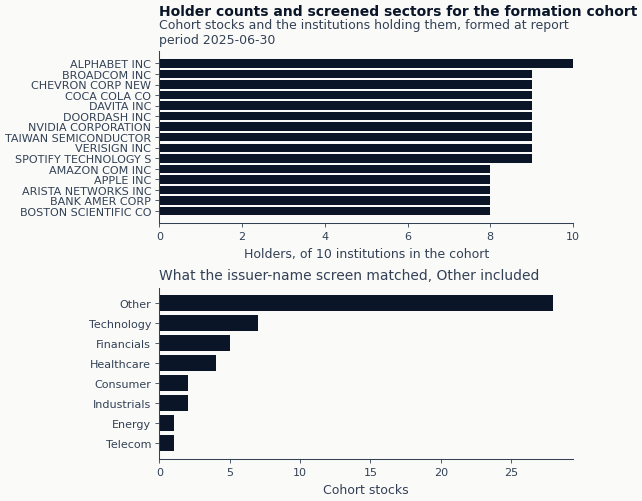

In [28]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)

# Panel (a): most widely held names, against the cohort size
stock_holders = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        stock_holders[edge.target_id] = stock_holders.get(edge.target_id, 0) + 1

sorted_stocks = sorted(stock_holders.items(), key=lambda x: (-x[1], x[0]))[:15]
names = []
for cusip, _ in sorted_stocks:
    match = [s for s in data_stocks if s["cusip"] == cusip]
    names.append(match[0]["label"] if match else cusip[:10])
counts = [c for _, c in sorted_stocks]
panel_span = (min(counts), max(counts))
axes[0].barh(range(len(names)), counts, color=COLORS["blue"])
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel(f"Holders, of {len(data_institutions)} institutions in the cohort")
axes[0].set_xlim(0, len(data_institutions))
axes[0].set_xticks(range(0, len(data_institutions) + 1, 2))
axes[0].invert_yaxis()

# Panel (b): what the sector name screen matched
sector_counts = {}
for stock in data_stocks:
    sector_counts[stock["sector"]] = sector_counts.get(stock["sector"], 0) + 1
sector_rows = sorted(sector_counts.items(), key=lambda item: (-item[1], item[0]))
sector_names = [row[0] for row in sector_rows]
scounts = [row[1] for row in sector_rows]
axes[1].barh(sector_names[::-1], scounts[::-1], color=COLORS["blue"])
axes[1].set_xlabel("Cohort stocks")
axes[1].set_title("What the issuer-name screen matched, Other included", loc="left")

add_message_title(
    axes[0],
    "Holder counts and screened sectors for the formation cohort",
    subtitle=(
        "Cohort stocks and the institutions holding them, "
        f"formed at report period {period_calendar['report_date'][0]}"
    ),
)
show_with_alt(
    fig,
    f"Two stacked panels. The upper one has horizontal bars for the {len(names)} most "
    "widely held "
    "stocks, labelled by shortened issuer name, on an axis running from zero to "
    f"{len(data_institutions)} possible holders. The bars run from {panel_span[0]} to "
    f"{panel_span[1]} holders, so they all end in a narrow band near the right edge and "
    "the ordering between them is a difference of one or two holders. The lower one has "
    "horizontal bars counting cohort stocks per screened sector, longest first, led by "
    f"{sector_names[0]} at {scounts[0]} of {len(data_stocks)}.",
)

The top panel describes holder overlap inside a fixed ten-institution cohort;
it does not measure the price impact of an unwind. The bottom panel describes
the name screen, not the market: "Other" is where an issuer whose name nobody
wrote into `SECTOR_TERMS` lands, so its length is a property of the term list.

## 6. Top Holdings by Sector

Query combining holdings with sector information (or overall if no sectors).

In [29]:
# Get unique sectors
unique_sectors = set(s.get("sector", "Unknown") for s in data_stocks)
sector_to_analyze = "Technology" if "Technology" in unique_sectors else sorted(unique_sectors)[0]

print(f"QUERY 4: Top Holdings in {sector_to_analyze} Sector")
print()
print("Cypher equivalent:")
print(f"""
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)-[:IN_SECTOR]->(sec:Sector {{name: '{sector_to_analyze}'}})
WITH s, SUM(h.value) AS total_ownership
RETURN s.label, s.issuer, total_ownership
ORDER BY total_ownership DESC
LIMIT 10
""")

QUERY 4: Top Holdings in Technology Sector

Cypher equivalent:

MATCH (i:Institution)-[h:HOLDS]->(s:Stock)-[:IN_SECTOR]->(sec:Sector {name: 'Technology'})
WITH s, SUM(h.value) AS total_ownership
RETURN s.label, s.issuer, total_ownership
ORDER BY total_ownership DESC
LIMIT 10



In [30]:
# Find stocks in sector and sum institutional ownership
sector_cusips = {s["cusip"] for s in data_stocks if s.get("sector") == sector_to_analyze}
print(f"\nStocks in {sector_to_analyze}: {len(sector_cusips)}")

sector_ownership: dict[str, int] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS" and edge.target_id in sector_cusips:
        if edge.target_id not in sector_ownership:
            sector_ownership[edge.target_id] = 0
        sector_ownership[edge.target_id] += edge.properties["value"]


Stocks in Technology: 7


In [31]:
# Format and display results
print(f"Top Holdings in {sector_to_analyze}:")
sector_data = []
for cusip, value in sector_ownership.items():
    stock = graph.get_node(cusip)
    if stock:
        sector_data.append(
            {
                "stock": stock.properties.get("label", ""),
                "issuer": stock.properties.get("issuer", cusip),
                "total_ownership_bn": value / 1_000_000_000,
            }
        )

sector_df = pl.DataFrame(sector_data).sort(
    ["total_ownership_bn", "stock"], descending=[True, False]
)
sector_df.head(10)

Top Holdings in Technology:


stock,issuer,total_ownership_bn
str,str,f64
"""APPLE INC""","""APPLE INC""",66.682616
"""ALPHABET INC""","""ALPHABET INC""",24.458789
"""NVIDIA CORPORATION""","""NVIDIA CORPORATION""",17.807604
"""MICROSOFT CORP""","""MICROSOFT CORP""",9.439988
"""BROADCOM INC""","""BROADCOM INC""",8.187854
"""META PLATFORMS INC""","""META PLATFORMS INC""",6.914246
"""TAIWAN SEMICONDUCTOR""","""TAIWAN SEMICONDUCTOR MFG LTD""",6.246909


## 7. Neo4j Loading

Load to Neo4j.

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

In [32]:
INSTITUTION_QUERY = """
UNWIND $rows AS row
MERGE (i:Institution {cik: row.cik})
SET i.name = row.name, i.equity_13f_value = row.equity_13f_value
"""

STOCK_QUERY = """
UNWIND $rows AS row
MERGE (s:Stock {cusip: row.cusip})
SET s.label = row.label, s.issuer = row.issuer, s.sector = row.sector
MERGE (sector:Sector {name: row.sector})
MERGE (s)-[:IN_SECTOR]->(sector)
"""

HOLDING_QUERY = """
UNWIND $rows AS row
MATCH (i:Institution {cik: row.cik})
MATCH (s:Stock {cusip: row.cusip})
MERGE (i)-[h:HOLDS {report_date: row.report_date}]->(s)
SET h.shares = row.shares, h.value = row.value, h.available_from = row.available_from
"""

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

### Neo4j Constraints

Create uniqueness constraints before loading records so repeated runs remain
idempotent and the graph enforces one node per institution or stock key.

In [33]:
def ensure_neo4j_constraints(session) -> None:
    """Create the constraints required by the holdings graph."""
    constraints = [
        "CREATE CONSTRAINT IF NOT EXISTS FOR (i:Institution) REQUIRE i.cik IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:Stock) REQUIRE s.cusip IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:Sector) REQUIRE s.name IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:GraphSnapshot) REQUIRE s.name IS UNIQUE",
    ]
    for constraint in constraints:
        session.run(constraint).consume()

### Holdings-Subgraph Reset

Replace only the labels owned by this producer so unrelated chapter graphs remain intact.

In [34]:
def clear_holdings_subgraph(session) -> None:
    """Clear only node labels owned by the 13F producer."""
    session.run("MATCH (n) WHERE n:Institution OR n:Stock OR n:Sector DETACH DELETE n").consume()

In [35]:
def build_graph_snapshot(holding_rows: list[dict[str, Any]]) -> dict[str, Any]:
    """Record the source bytes, cohort policy, report periods, and graph counts.

    A consumer reads its own cutoff from this node instead of restating one.
    `03_graph_rag_qa` pinned the literal "2026-02-17" and broke the first time
    the artifact rolled a quarter forward; `latest_available_from` is the same
    fact, written once by the producer.
    """
    periods = sorted({row["report_date"] for row in holding_rows})
    return {
        "name": "ch23_13f",
        "source_sha256": SOURCE_SHA256,
        "source_rows": SOURCE_ROWS,
        "formation_report_date": periods[0],
        "latest_report_date": periods[-1],
        "latest_available_from": max(row["available_from"] for row in holding_rows),
        "report_period_count": len(periods),
        "institution_count": len(data_institutions),
        "stock_count": len(data_stocks),
        "holding_count": len(holding_rows),
        "cohort_policy": "earliest-report-period formation, fixed forward",
        "position_basis": "long equity only; reported put and call rows excluded",
    }

In [36]:
def read_graph_counts(session) -> dict[str, int]:
    """Read the exact holdings-subgraph counts after loading."""
    return (
        session.run(
            """
        MATCH (i:Institution) WITH count(i) AS institutions
        MATCH (s:Stock) WITH institutions, count(s) AS stocks
        MATCH (:Institution)-[h:HOLDS]->(:Stock)
        WITH institutions, stocks, count(h) AS holdings
        MATCH (:Stock)-[r:IN_SECTOR]->(:Sector)
        RETURN institutions, stocks, holdings, count(r) AS sector_edges
        """
        )
        .single()
        .data()
    )

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

In [37]:
def load_13f_to_neo4j() -> dict:
    """Load 13F data to Neo4j database.

    Returns stats dict with counts of loaded entities/relationships.
    """
    holding_rows = data_holdings_all_periods
    snapshot = build_graph_snapshot(holding_rows)
    print("Loading to Neo4j...")
    with NEO4J_DRIVER.session() as session:
        ensure_neo4j_constraints(session)
        clear_holdings_subgraph(session)
        session.run(INSTITUTION_QUERY, rows=data_institutions).consume()
        session.run(STOCK_QUERY, rows=data_stocks).consume()
        session.run(HOLDING_QUERY, rows=holding_rows).consume()
        session.run(
            "MERGE (s:GraphSnapshot {name: $snapshot.name}) SET s = $snapshot",
            snapshot=snapshot,
        ).consume()
        stats = read_graph_counts(session)
    expected = {
        "institutions": len(data_institutions),
        "stocks": len(data_stocks),
        "holdings": len(holding_rows),
        "sector_edges": len(data_stocks),
    }
    assert stats == expected, f"Neo4j load mismatch: {stats=} {expected=}"
    print(f"Loaded and verified: {stats}")
    print(f"Graph snapshot: {snapshot}")
    return {**stats, **snapshot}

In [38]:
# Load to Neo4j
neo4j_stats = load_13f_to_neo4j()

Loading to Neo4j...


Loaded and verified: {'institutions': 10, 'stocks': 50, 'holdings': 1463, 'sector_edges': 50}
Graph snapshot: {'name': 'ch23_13f', 'source_sha256': 'd2a67317195dd431f00e3408c1ba4e6bf8b44b3eae2f838cbbd90fabca69ef0d', 'source_rows': 209316, 'formation_report_date': '2025-06-30', 'latest_report_date': '2026-03-31', 'latest_available_from': '2026-05-15', 'report_period_count': 4, 'institution_count': 10, 'stock_count': 50, 'holding_count': 1463, 'cohort_policy': 'earliest-report-period formation, fixed forward', 'position_basis': 'long equity only; reported put and call rows excluded'}


## 8. Summary Statistics

Two graphs were built here and they are different sizes. The in-memory graph
carries the latest report period only, which is what §4-6 queried; Neo4j
carries every period, which is what `03_graph_rag_qa` needs to answer an
as-of question. Each row below says which one it counts.

In [39]:
# Compute statistics
n_institutions = len(data_institutions)
n_stocks = len(data_stocks)
n_holdings = len(data_holdings)
n_sectors = len(sectors)

avg_holdings_per_inst = n_holdings / n_institutions if n_institutions > 0 else 0
avg_holders_per_stock = n_holdings / n_stocks if n_stocks > 0 else 0

max_crowding = max(len(h) for h in stock_holder_sets.values()) if stock_holder_sets else 0
most_crowded = []
for c, h in stock_holder_sets.items():
    if len(h) == max_crowding:
        node = graph.get_node(c)
        if node:
            name = node.properties.get("label") or node.properties.get("issuer", c)
            most_crowded.append(name)

max_sim = sim_df.row(0) if len(sim_df) > 0 else None

n_period_holdings = len(data_holdings_all_periods)
n_periods = len({row["report_date"] for row in data_holdings_all_periods})

In [40]:
summary_rows = [
    ("Data source", data_source),
    ("Institutions", n_institutions),
    ("Stocks", n_stocks),
    ("Sectors", n_sectors),
    ("HOLDS edges in the in-memory graph (latest period)", n_holdings),
    (
        "HOLDS edges in Neo4j",
        f"{n_period_holdings} across {n_periods} report periods",
    ),
    ("Avg holdings per institution (latest period)", f"{avg_holdings_per_inst:.1f}"),
    ("Avg holders per stock (latest period)", f"{avg_holders_per_stock:.1f}"),
    ("Max holders on one stock", f"{max_crowding} of {n_institutions}"),
    ("Stock pairs sharing a holder", len(sim_df)),
    ("Neo4j loaded", "Yes" if NEO4J_DRIVER else "No"),
]
if most_crowded:
    most_crowded.sort()
    summary_rows.insert(8, ("Most crowded stocks", ", ".join(most_crowded[:5])))
if max_sim:
    summary_rows.insert(
        -1,
        (
            "Pairs tied at the highest similarity",
            f"{len(top_group)} at {top_value:.3f}",
        ),
    )
summary_df = pl.DataFrame(
    {"Metric": [r[0] for r in summary_rows], "Value": [str(r[1]) for r in summary_rows]}
)
summary_df

Metric,Value
str,str
"""Data source""","""EDGAR 13F"""
"""Institutions""","""10"""
"""Stocks""","""50"""
"""Sectors""","""8"""
"""HOLDS edges in the in-memory graph (latest period)""","""363"""
"""HOLDS edges in Neo4j""","""1463 across 4 report periods"""
"""Avg holdings per institution (latest period)""","""36.3"""
"""Avg holders per stock (latest period)""","""7.3"""
"""Most crowded stocks""","""ALPHABET INC"""


Every count above comes from the executed graph, and every one of them is
reachable from the flat 13F table with a groupby. What the graph buys is the
multi-hop question: "stocks connected to this manager's holdings through any
other holder" is one traversal here and a chain of self-joins there. Nothing
in this table is a market measurement - the cohort is ten managers and fifty
names, chosen by size.

## 9. Verification

In [41]:
print(f"Data source: {data_source}")
print(f"Neo4j: {'Connected' if NEO4J_DRIVER else 'Not connected'}")
print(f"Graph: {len(graph.nodes)} nodes, {len(graph.edges)} edges")
print("Queries demonstrated: 4")
print(f"Co-ownership pairs computed: {len(similarities)}")
print()
if most_crowded:
    crowded_str = ", ".join(most_crowded[:3])
    print(f"Highest observed holder count: {crowded_str} ({max_crowding} holders)")
    print("This is descriptive ownership overlap; return effects are not evaluated.")

completion_record = {
    "source_sha256": SOURCE_SHA256,
    "source_rows": SOURCE_ROWS,
    "formation_report_date": neo4j_stats["formation_report_date"],
    "latest_report_date": neo4j_stats["latest_report_date"],
    "latest_available_from": neo4j_stats["latest_available_from"],
    "report_period_count": n_periods,
    "institutions": n_institutions,
    "stocks": n_stocks,
    "holdings_latest": n_holdings,
    "holdings_all_periods": n_period_holdings,
    "sector_edges": neo4j_stats["sector_edges"],
    "graph_nodes": len(graph.nodes),
    "graph_edges": len(graph.edges),
    "shared_holding_pairs": len(similarities),
    "max_holder_count": max_crowding,
    "highest_jaccard": float(max_sim[2]) if max_sim else None,
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))
NEO4J_DRIVER.close()

Data source: EDGAR 13F
Neo4j: Connected
Graph: 68 nodes, 413 edges
Queries demonstrated: 4
Co-ownership pairs computed: 1176

Highest observed holder count: ALPHABET INC (10 holders)
This is descriptive ownership overlap; return effects are not evaluated.
COMPLETION_RECORD={"formation_report_date": "2025-06-30", "graph_edges": 413, "graph_nodes": 68, "highest_jaccard": 1.0, "holdings_all_periods": 1463, "holdings_latest": 363, "institutions": 10, "latest_available_from": "2026-05-15", "latest_report_date": "2026-03-31", "max_holder_count": 10, "report_period_count": 4, "sector_edges": 50, "shared_holding_pairs": 1176, "source_rows": 209316, "source_sha256": "d2a67317195dd431f00e3408c1ba4e6bf8b44b3eae2f838cbbd90fabca69ef0d", "stocks": 50}


## Key Takeaways

1. **13F filings form a bipartite graph**: institutions connected to stocks
   through HOLDS edges carrying value, share count, the report period the
   position is as of, and the filing date it became public. Two dates, because
   a quarter-over-quarter comparison and a point-in-time query need different
   ones, and using either for the other question is a look-ahead in one
   direction and a misaligned quarter in the other.

2. **A 13F is not a portfolio, and its option rows are not ownership.** A put
   disclosed on an issuer profits when the issuer falls, and summing it into
   the same `value` as the shares makes a short view indistinguishable from a
   long one. The run prints how much was excluded on that basis; it is not a
   rounding-sized share of the reported total, and it reorders the managers by
   size when you put it back in. `22_rag_financial_research/07` makes the same
   exclusion for the same reason.

3. **Graph queries express ownership patterns directly**: shared holdings,
   network paths, and multi-hop sector aggregations are single Cypher
   traversals; the equivalent SQL requires self-joins on the holdings table.
   This notebook does not benchmark Cypher against SQL execution time.

4. **A similarity over ten possible holders is coarse.** Jaccard scores here
   are ratios of small integers, so the pairs bunch onto a handful of values
   and the top of a sorted list is a tie broken alphabetically. The run reports
   how many pairs sit on the top value instead of printing ten of them as a
   ranking. Whether co-ownership structure relates to return correlation is
   not measured here, and a cohort this size could not resolve it.

5. **The security is the CUSIP, not the name.** Managers spell the same
   issuer differently in the same quarter, and grouping positions on
   `(cusip, issuer)` puts both spellings into the cohort as separate stocks.
   Neo4j `MERGE`s on the CUSIP and collapses them back, so the cohort would
   have claimed a size the graph did not have - the load-count assertion is
   what caught it. The run prints which CUSIPs were merged.

6. **Two counts of "the graph" are two graphs.** The in-memory graph holds the
   latest report period, which is what §4-6 query; Neo4j holds every period,
   which is what `03_graph_rag_qa` needs. The summary table names which one
   each row counts, and `GraphSnapshot` records the same facts for consumers
   so they read the cutoff rather than restate it.

**Next**: See `07_dynamic_kg_temporal` for how this ownership graph evolves over
time, enabling trend detection in institutional positioning.

**Book**: Section 23.4 discusses ownership-graph features (crowding, smart-
money concentration, ownership HHI, co-ownership Jaccard); Section 23.7
covers the production engineering decisions for KG schema and incremental
quarterly updates from EDGAR.